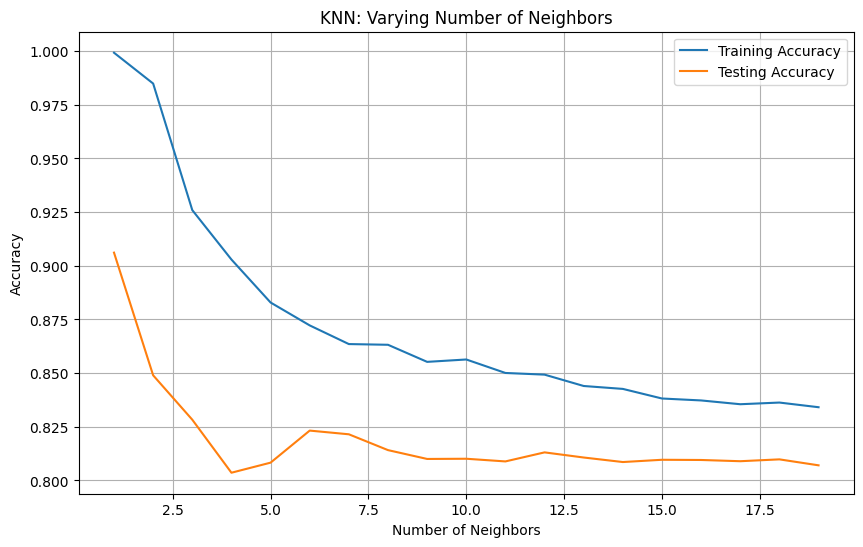

Meilleur n_neighbors: 1

Accuracy sur l'ensemble de test: 0.9061064318529862
Score moyen de validation croisée: 0.9239339554917445

Rapport de Classification:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      5721
           1       0.69      0.92      0.79       788
           2       0.89      0.97      0.93      3939

    accuracy                           0.91     10448
   macro avg       0.85      0.92      0.88     10448
weighted avg       0.92      0.91      0.91     10448


Matrice de Confusion:
[[4926  331  464]
 [  57  728    3]
 [ 126    0 3813]]


['dino_model_knn.pkl']

In [16]:
# Modele KNN
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

data_df = pd.read_csv('dino_run_logs.csv')
X = data_df.drop(["type_obstacle", "is_jumping", "action_label"], axis = 1).to_numpy()
y = data_df["action_label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

# Hyperparameter tuning for n_neighbors
neighbors = np.arange(1, 20)
train_accuracy = []
test_accuracy = []

for n_neighbor in neighbors:
    steps = [
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors = n_neighbor))
    ]
    pipeline_knn = Pipeline(steps)
    pipeline_knn.fit(X_train, y_train)
    train_accuracy.append(pipeline_knn.score(X_train, y_train))
    test_accuracy.append(pipeline_knn.score(X_test, y_test))

# Plotting the accuracy for different n_neighbors
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracy, label='Training Accuracy')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy')
plt.title('KNN: Varying Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Find the best n_neighbors
best_n_neighbors_index = np.argmax(test_accuracy)
best_n_neighbors = neighbors[best_n_neighbors_index]
print(f"Meilleur n_neighbors: {best_n_neighbors}")

# Train the final model with the best n_neighbors
final_steps = [
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors = best_n_neighbors))
]
final_pipeline = Pipeline(final_steps)
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

# Evaluate the final model
print(f"\nAccuracy sur l'ensemble de test: {accuracy_score(y_test, y_pred)}")
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
scores = cross_val_score(final_pipeline, X, y, cv = kf)
print(f"Score moyen de validation croisée: {scores.mean()}")
print("\nRapport de Classification:")
print(classification_report(y_test, y_pred))
print("\nMatrice de Confusion:")
print(confusion_matrix(y_test, y_pred))

# Save the best model
joblib.dump(final_pipeline, 'dino_model_knn.pkl')

In [17]:
# Modele de Regression logistique
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss

data_df = pd.read_csv('dino_run_logs.csv')
X = data_df.drop(["type_obstacle","is_jumping", "action_label"], axis = 1).to_numpy()
y = data_df["action_label"].to_numpy()
steps = [
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial', class_weight= 'balanced'))
]
pipeline = Pipeline(steps)
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)
logreg_scaled = pipeline.fit(X_train, y_train)
y_pred = logreg_scaled.predict(X_test)
y_pred_probs = logreg_scaled.predict_proba(X_test)

print(f"Accuracy on test set (from .score()): {logreg_scaled.score(X_test, y_test)}")
print(f"Accuracy on test set (from accuracy_score): {accuracy_score(y_test, y_pred)}")
print(f"Log Loss on test set: {log_loss(y_test, y_pred_probs)}")

scores = cross_val_score(pipeline, X, y, cv = kf)
print(f"Mean cross-validation score: {scores.mean()}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

joblib.dump(pipeline, 'dino_model_logreg.pkl')


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy on test set (from .score()): 0.5653713629402757
Accuracy on test set (from accuracy_score): 0.5653713629402757
Log Loss on test set: 0.9315117169248132


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Mean cross-validation score: 0.5667767408470926

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.41      0.51      5721
           1       0.23      0.93      0.37       788
           2       0.74      0.72      0.73      3939

    accuracy                           0.57     10448
   macro avg       0.55      0.69      0.54     10448
weighted avg       0.67      0.57      0.58     10448


Confusion Matrix:
[[2337 2392  992]
 [  38  731   19]
 [1074   26 2839]]


['dino_model_logreg.pkl']